# Logistic Regression -  Loan approval dataset

## Loading the dataset and importing the modules

In [34]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import seaborn as sns


In [35]:
df = pd.read_csv("../datasets/loan_data.csv")
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [36]:
# df.corr()

**conclusion:**
- Since there is no multicollinearity problem , between the features , we can conclude  model will not overfit.

## Data preparation

### Splitting data into x and y

In [37]:
x = df.drop("loan_status", axis=1)
y = df["loan_status"]

x

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No


In [38]:
y

0        1
1        0
2        1
3        1
4        1
        ..
44995    1
44996    1
44997    1
44998    1
44999    1
Name: loan_status, Length: 45000, dtype: int64

### Splitting data into train and test

In [39]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
xtrain

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
25180,34.0,female,Bachelor,97265.0,11,MORTGAGE,15000.0,PERSONAL,12.73,0.15,9.0,631,No
12555,25.0,male,High School,72953.0,3,RENT,12000.0,VENTURE,11.86,0.16,4.0,659,Yes
29153,41.0,female,Master,322597.0,18,MORTGAGE,24000.0,PERSONAL,10.37,0.07,11.0,683,Yes
23838,27.0,male,Associate,94232.0,4,RENT,9600.0,EDUCATION,17.14,0.10,7.0,641,No
35686,27.0,male,Master,84873.0,7,RENT,7059.0,HOMEIMPROVEMENT,12.97,0.08,3.0,706,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,26.0,male,High School,88451.0,6,MORTGAGE,10625.0,EDUCATION,6.03,0.12,4.0,559,Yes
44732,25.0,female,High School,34772.0,3,MORTGAGE,5876.0,HOMEIMPROVEMENT,11.69,0.17,4.0,647,No
38158,33.0,female,Associate,58317.0,9,MORTGAGE,10707.0,VENTURE,10.74,0.18,9.0,652,Yes
860,26.0,male,Master,178602.0,6,RENT,20000.0,DEBTCONSOLIDATION,17.99,0.11,3.0,604,No


In [41]:
xtest

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
37979,32.0,male,Associate,96865.0,10,MORTGAGE,7500.0,EDUCATION,6.04,0.08,10.0,601,No
9911,24.0,male,Associate,56838.0,6,RENT,9000.0,EDUCATION,11.49,0.16,4.0,647,Yes
43386,22.0,female,Master,37298.0,0,RENT,5000.0,MEDICAL,14.88,0.13,4.0,711,No
13822,23.0,female,Bachelor,39944.0,1,OWN,5000.0,VENTURE,13.99,0.13,3.0,597,Yes
44810,42.0,male,High School,67974.0,20,MORTGAGE,10000.0,HOMEIMPROVEMENT,15.41,0.15,11.0,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,21.0,male,Bachelor,133205.0,0,MORTGAGE,14000.0,VENTURE,9.99,0.11,2.0,654,No
30384,39.0,male,High School,61889.0,17,RENT,6725.0,EDUCATION,16.45,0.11,11.0,606,Yes
36665,24.0,female,Master,78950.0,1,RENT,14000.0,EDUCATION,11.65,0.18,3.0,614,No
30569,38.0,male,Associate,37142.0,16,RENT,8000.0,MEDICAL,11.01,0.22,14.0,695,No


In [42]:
ytrain

25180    0
12555    0
29153    0
23838    0
35686    0
        ..
11284    0
44732    1
38158    0
860      1
15795    0
Name: loan_status, Length: 36000, dtype: int64

In [43]:
ytest

37979    0
9911     0
43386    1
13822    0
44810    1
        ..
14572    0
30384    0
36665    0
30569    0
5321     0
Name: loan_status, Length: 9000, dtype: int64

### diving the numreical and object columns

In [44]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

print(obj_cols) # this contains only categorical data
print(num_cols) # this contains only numerical data
df.dtypes

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')
Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='str')


C:\Users\shankar paikira\AppData\Local\Temp\ipykernel_26816\3490873176.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = x.select_dtypes(include='object').columns


person_age                        float64
person_gender                         str
person_education                      str
person_income                     float64
person_emp_exp                      int64
person_home_ownership                 str
loan_amnt                         float64
loan_intent                           str
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file        str
loan_status                         int64
dtype: object

## Checking for outliers and performing scaling and Model training

<Axes: >

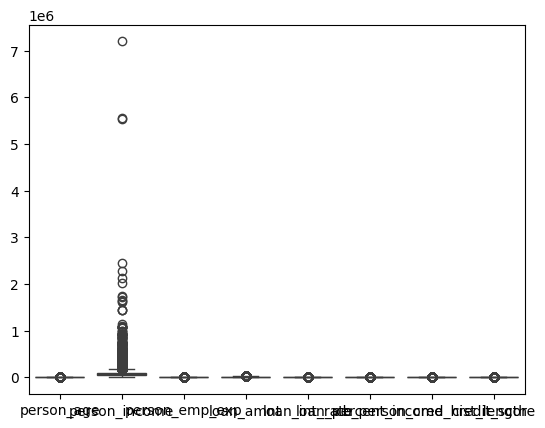

In [45]:
# check the ouliers using box plot

sns.boxplot(x[num_cols])

In [71]:
x[num_cols].corr()

# df[num_cols].corr() shows correlation only between the numeric feature columns in num_cols.
# It does not include your label/target column unless you add it.

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
person_age,1.000000,0.193698,0.954412,0.050750,0.013402,-0.043299,0.861985,0.178432
person_income,0.193698,1.000000,0.185987,0.242290,0.001510,-0.234177,0.124316,0.035919
person_emp_exp,0.954412,0.185987,1.000000,0.044589,0.016631,-0.039862,0.824272,0.186196
loan_amnt,0.050750,0.242290,0.044589,1.000000,0.146093,0.593011,0.042969,0.009074
loan_int_rate,0.013402,0.001510,0.016631,0.146093,1.000000,0.125209,0.018008,0.011498
loan_percent_income,-0.043299,-0.234177,-0.039862,0.593011,0.125209,1.000000,-0.031868,-0.011483
cb_person_cred_hist_length,0.861985,0.124316,0.824272,0.042969,0.018008,-0.031868,1.000000,0.155204
credit_score,0.178432,0.035919,0.186196,0.009074,0.011498,-0.011483,0.155204,1.000000


**conclusion:**
- Since there is multicollinearity problem , between the features , we can conclude  model may overfit.

In [49]:
# count the unique values present in colummn (object) - here also we cxa use onehotencoder due to less unique values
x[obj_cols].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

**Preprocessing techniques:**
- Scaling 
- Encoding

1. **_Why Scaling?_**
- Feature column values are in diffrent range (scale) of values 
- So we use scaling to give equal importance for all the feature columns.
- Scaling is applied on numerical columns.

2. **_Why Encoding?_**
- Algorithms can understand only the numbers not strings 
- We convert the strings in the number format using encoding, so encoding is applied on obj column

--- 
**Which scaling to be used for the above dataset ?**
- Based on outliers we can select the **scaling** technique
- since there are no outliers we will use **MinMaxscaler**

**Which encoding to be used for the above dataset ?**
- Loan_Term - 4, Employee_Status - 3, Residence_Type - 3, Previous_Default- 2
- Since there are very few unique values we can use **OneHotEncoding**


In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
scaling = RobustScaler()

# model = LogisticRegression() # default penalty='l2'
# model = LogisticRegression(penalty='l1', solver='liblinear') # try with this also to check the performance how the model is working
model = LogisticRegression(penalty = None)



In [ ]:
#xtrain

xtrain[num_cols] = scaling.fit_transform(xtrain[num_cols])

# xtrain[obj_cols] = scaling.fit_transform(xtrain[obj_cols]) # error we have 19 unique vlaues but only for four ctaegoricla column

encoded_values = encoder.fit_transform(xtrain[obj_cols])
encoded_columns = encoder.get_feature_names_out()

xtrain[encoded_columns] = encoded_values
xtrain.drop(columns = obj_cols, inplace=True)


In [52]:
xtrain

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
25180,1.333333,0.621771,1.000000,0.965517,0.386517,0.250000,1.0,-0.132353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
12555,-0.166667,0.120777,-0.142857,0.551724,0.191011,0.333333,0.0,0.279412,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
29153,2.500000,5.265159,2.000000,2.206897,-0.143820,-0.416667,1.4,0.632353,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
23838,0.166667,0.559271,0.000000,0.220690,1.377528,-0.166667,0.6,0.014706,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
35686,0.166667,0.366411,0.428571,-0.129793,0.440449,-0.333333,-0.2,0.970588,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.000000,0.440142,0.285714,0.362069,-1.119101,0.000000,0.0,-1.191176,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
44732,-0.166667,-0.666014,-0.142857,-0.292966,0.152809,0.416667,0.0,0.102941,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
38158,1.166667,-0.180825,0.714286,0.373379,-0.060674,0.500000,1.0,0.176471,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
860,0.000000,2.297872,0.285714,1.655172,1.568539,-0.083333,-0.2,-0.529412,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [53]:
# xtest

xtest[num_cols] = scaling.transform(xtest[num_cols])

# xtest[obj_cols] = scaling.transform(xtest[obj_cols]) # error we have 12 unique vlaues but only for four ctaegoricla column

encoded_values = encoder.transform(xtest[obj_cols])


xtest[encoded_columns] = encoded_values
xtest.drop(columns = obj_cols, inplace=True)

In [54]:
xtest

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
37979,1.000000,0.613528,0.857143,-0.068966,-1.116854,-0.333333,1.2,-0.573529,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
9911,-0.333333,-0.211303,0.285714,0.137931,0.107865,0.333333,0.0,0.102941,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
43386,-0.666667,-0.613961,-0.571429,-0.413793,0.869663,0.083333,0.0,1.044118,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13822,-0.500000,-0.559435,-0.428571,-0.413793,0.669663,0.083333,-0.2,-0.632353,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
44810,2.666667,0.018175,2.285714,0.275862,0.988764,0.250000,1.4,-0.794118,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14572,-0.833333,1.362382,-0.571429,0.827586,-0.229213,-0.083333,-0.4,0.205882,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
30384,2.166667,-0.107218,1.857143,-0.175862,1.222472,-0.083333,1.4,-0.500000,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
36665,-0.333333,0.244356,-0.428571,0.827586,0.143820,0.500000,-0.2,-0.382353,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
30569,2.000000,-0.617176,1.714286,0.000000,0.000000,0.833333,2.0,0.808824,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [72]:
model.fit(xtrain, ytrain) 
# we have done inpace=True so it updaetd the original datset itself , we doint stoe in anynew ariable like updated_xtrain or updated_xtest

d:\PySpiders\pyspiders -ML\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

## Evaluation

In [56]:
y_pred_train = model.predict(xtrain)

In [57]:
y_pred_test = model.predict(xtest)

### Train data Evaluation

In [58]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

confusion_train = confusion_matrix(ytrain, y_pred_train)

confusion_train

array([[26311,  1699],
       [ 2002,  5988]])

**conclusion:** 
- Dataset is unbalanced
- 

In [60]:
ytrain.value_counts()

loan_status
0    28010
1     7990
Name: count, dtype: int64

In [61]:
predicted_yes = np.sum(confusion_train[:,1]) # all rows , 1st column index
predicted_no = np.sum(confusion_train[:,0]) # all rows , 0th column index

print(predicted_yes)
print(predicted_no)


7687
28313


In [66]:
precision_score(ytrain, y_pred_train, pos_label=1) # by default pos_label = 1
# this is the precison_score of Yes(1)

0.7789774944711851

`Conclusion`:
- Out of all the predicted `Yes` labels(425), 54% labels are correctly predicted as `Yes`
- Out of all the predicted `No` labels(375), 46% labels are correctly predicted as `No`

In [67]:
precision_score(ytrain, y_pred_train, pos_label=0) 
# this is the precison_score of No

0.9292904319570515

`Conclusion`:
- Out of all the predicted `No` labels(375), 54% labels are correctly predicted as `No`
- Out of all the predicted `Yes` labels(425), 46% labels are correctly predicted as `Yes`

In [68]:
recall_score(ytrain, y_pred_train, pos_label=1)


0.7494367959949937

`Conclusion`:
- Out of all the actual(train data only) `Yes` labels(403), 57% labels are correctly predicted as `Yes`
- Out of all the actual `Yes` labels(403), 43% labels are wrongly predicted as `Yes`

In [69]:
recall_score(ytrain, y_pred_train, pos_label=0)


0.9393430917529454

`Conclusion`:
- Out of all the actual(train data only) `No` labels(397), 51% labels are correctly predicted as `No`
- Out of all the actual `No` labels(397), 49% labels are wrongly predicted as `No`

From this we conclude that, the class label is balanced

In [70]:
accuracy_score(ytrain, y_pred_train)

0.8971944444444444

`Conclusion`:
- Out of all the samples(800) , 54.75% samples are correctly predicted

`Final Conclusion`:
Model performance on train data is bad, so model is not learned train data patterns properly


- Model is underfit , model is too simple and not able to capture complex pattern
(this is for overall consulin after test data)

In [90]:
from sklearn.metrics import classification_report
print(classification_report(ytrain, y_pred_train))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     28010
           1       0.78      0.75      0.76      7990

    accuracy                           0.90     36000
   macro avg       0.85      0.84      0.85     36000
weighted avg       0.90      0.90      0.90     36000



### Test Data Evaluation

In [73]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

confusion_test = confusion_matrix(ytest, y_pred_test)

confusion_test

array([[6555,  435],
       [ 519, 1491]])

In [75]:
ytest.value_counts()

loan_status
0    6990
1    2010
Name: count, dtype: int64

**conclusion:** 
- Dataset is unbalanced
- 

In [85]:
predicted_yes = np.sum(confusion_test[:,1]) # all rows , 1st column index
predicted_no = np.sum(confusion_test[:,0]) # all rows , 0th column index

print(predicted_yes)
print(predicted_no)


1926
7074


In [84]:
precision_score(ytest, y_pred_test, pos_label=1) # by default pos_label = 1
# this is the precison_score of Yes(1)

0.7741433021806854

In [82]:
precision_score(ytest, y_pred_test, pos_label=0) 
# this is the precison_score of No

0.9266327396098388

In [80]:
recall_score(ytest, y_pred_test, pos_label=1)


0.7417910447761195

In [86]:
recall_score(ytest, y_pred_test, pos_label=0)


0.9377682403433476

In [88]:
accuracy_score(ytest, y_pred_test)

0.894

In [ ]:
f1_score(ytest, y_pred_test) # if data is unbalnced use f1 score and then macro avg of f1-score

0.7576219512195121